# Modelo Random Forest

#### Importamos la librería

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Cargamos el dataset

In [5]:
df = pd.read_csv("data_input.csv")
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)
df = df.drop(columns=['Unnamed: 0'])

In [6]:
df.head()

,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,conditions_Snow,temp_y,Unidades_y,conditions_Clear_y,"conditions_Rain, Overcast",CodigoArticulo_940-001,CodigoArticulo_940-005,CodigoArticulo_940-010,CodigoArticulo_940-012,CodigoArticulo_940-015,CodigoArticulo_940-506,CodigoArticulo_940-508,CodigoArticulo_940-511,CodigoArticulo_940-515,CodigoArticulo_940-520,CodigoArticulo_940-525,CodigoArticulo_R130101001
fecha,,,,,,,,,,,,,,,,,,,,
2021-01-03,0,2,0,0,2.500000,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-01-17,2,3,3,3,0.007143,1.0,6,0,0,1,0,0,0,0,0,0,0,0,0,0
2021-01-31,3,10,10,0,8.328571,0.0,1,3,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-14,0,14,10,0,9.614286,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-28,0,13,2,0,10.085714,4.0,1,0,0,0,0,0,0,0,0,0,2,0,2,0


In [7]:
df.dtypes

conditions_Overcast              int64
conditions_Partially cloudy      int64
conditions_Rain                  int64
conditions_Snow                  int64
temp_y                         float64
Unidades_y                     float64
conditions_Clear_y               int64
conditions_Rain, Overcast        int64
CodigoArticulo_940-001           int64
CodigoArticulo_940-005           int64
CodigoArticulo_940-010           int64
CodigoArticulo_940-012           int64
CodigoArticulo_940-015           int64
CodigoArticulo_940-506           int64
CodigoArticulo_940-508           int64
CodigoArticulo_940-511           int64
CodigoArticulo_940-515           int64
CodigoArticulo_940-520           int64
CodigoArticulo_940-525           int64
CodigoArticulo_R130101001        int64
dtype: object

#### Seleccionamos las variables X e Y

In [9]:
Y = df['Unidades_y']
df_X = df.drop(columns=['Unidades_y'])
X = df_X

#### Dividimos los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)

In [11]:
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [12]:
X_train, y_train = train.drop(columns=['Unidades_y']), train['Unidades_y']
X_test, y_test = test.drop(columns=['Unidades_y']), test['Unidades_y']

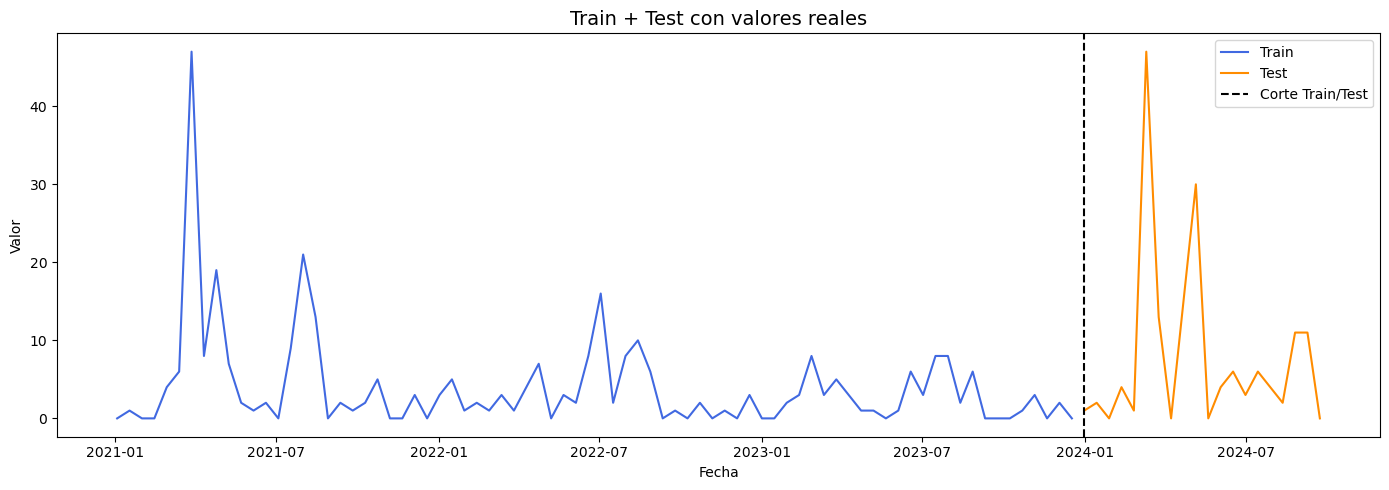

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df.index[:train_size], y_train, label='Train', color='royalblue')
plt.plot(df.index[train_size:], y_test, label='Test', color='darkorange')
plt.axvline(df.index[train_size], color='black', linestyle='--', label='Corte Train/Test')
plt.title("Train + Test con valores reales", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

#### Entrenamos el modelo

In [15]:
modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=10)
modelo_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200)

#### Realizamos predicciones en el conjunto de prueba

In [17]:
train_pred = modelo_rf.predict(X_train)
test_pred = modelo_rf.predict(X_test)

In [18]:
indice_predicciones_rf = pd.Series(train.index.tolist() + test.index.tolist())
valores_predichos_rf = np.concatenate([train_pred, test_pred])

#### Graficamos el resultado

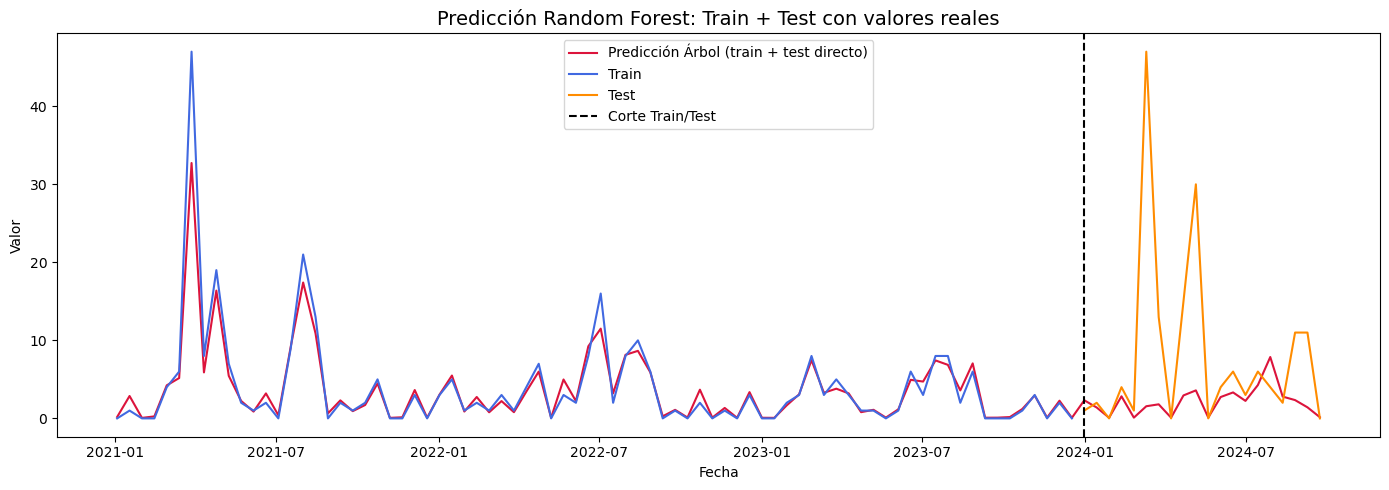

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(indice_predicciones_rf, valores_predichos_rf, label='Predicción Árbol (train + test directo)', color='crimson')
plt.plot(df.index[:train_size], y_train, label='Train', color='royalblue')
plt.plot(df.index[train_size:], y_test, label='Test', color='darkorange')
plt.axvline(df.index[train_size], color='black', linestyle='--', label='Corte Train/Test')
plt.title("Predicción Random Forest: Train + Test con valores reales", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

#### Evaluamos el modelo con el MSE

In [22]:
mse = mean_squared_error(y_test, test_pred)
mse

161.61979166239547

#### Evaluamos el modelo con el MAE

In [29]:
mae_train = mean_absolute_error(y_train, train_pred)
rmse_train = mean_squared_error(y_train, train_pred, squared=False)
r2_train = r2_score(y_train, train_pred)
mae_test = mean_absolute_error(y_test, test_pred)
rmse_test = mean_squared_error(y_test, test_pred, squared=False)
rmse_test = r2_score(y_test, test_pred)

In [53]:
print("MAE Train:", mae_train)
print("RMSE Train:", rmse_train)
print("R2 Train:", r2_train)
print("MAE Test:", mae_test)
print("RMSE Test:", rmse_test)
print("R2 Test:", r2_test)

MAE Train: 0.822172908433339
RMSE Train: 1.9236901687857837
R2 Train: 0.9119928066264344
MAE Test: 6.443466489554266
RMSE Test: 12.712977293395731
R2 Test: -0.24131944441163955
